# Cellular states identification

Clusters the MERFISH U2-OS cells on their gene-gene cosine similarity matrices, and compares the
resulting cell states by subcellular localization, splicing and co-localization.

Reads

- `train_merfish_U2OS.npz`, `test_merfish_U2OS.npz`, `gene_names.txt`, `cell_names.txt`,
  `gene2vec_weight_merfish_U2OS.npy`
- `splice_unsplice.npz` — the spliced and unspliced counts of each cell and gene
- `checkpoint_MERFISH_U2OS.pth` — the released checkpoint, from `../../../checkpoints`

Writes

- `latent_merfish_U2OS.npz` — by `merfish_U2OS/extract_latent.py`

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')

SVC_ROOT = Path(os.environ.get('SVC_ROOT', '../../..'))   # github.com/aster-ww/SVC
sys.path.insert(0, str(SVC_ROOT / 'merfish_U2OS'))
from cell_state import cell_states

DATA_ROOT = Path(os.environ.get('SVC_DATA_ROOT', '../../../data'))
DATA_DIR = DATA_ROOT / 'merfish_U2OS'
CKPT_DIR = Path('../../../checkpoints')
OUT_DIR = Path('../../../output/merfish_U2OS')

In [2]:
!python {SVC_ROOT}/merfish_U2OS/extract_latent.py --data-root {DATA_ROOT} --ckpt {CKPT_DIR}/checkpoint_MERFISH_U2OS.pth --out {OUT_DIR}/latent_merfish_U2OS.npz

  built kNN: N=900, k=4
[train] 900 cells
  built kNN: N=122, k=4
[test] 122 cells
saved ../../../output/merfish_U2OS/latent_merfish_U2OS.npz  (1022, 119, 384)


## Cell clustering

For each cell, the gene-gene cosine similarity matrix computed from its inferred latent
representation is flattened into a feature vector. Cells are then clustered by spectral clustering
on the Frobenius distance between these matrices.

In [3]:
N_CLUSTERS = 4

gene_names = np.loadtxt(DATA_DIR / 'gene_names.txt', dtype=str).tolist()
all_cell_names = np.loadtxt(DATA_DIR / 'cell_names.txt', dtype=str)
train = np.load(DATA_DIR / 'train_merfish_U2OS.npz', allow_pickle=True)
truth_train = train['data_ori']
train_cell_names = train['cell_names'].astype(str)

latent = np.load(OUT_DIR / 'latent_merfish_U2OS.npz', allow_pickle=True)
emb = latent['emb'][latent['split'] == 'train'].astype(np.float32)
n_cells, n_genes = emb.shape[0], emb.shape[1]

cosine, cluster_labels = cell_states(emb, N_CLUSTERS)
CLUSTERS = sorted(np.unique(cluster_labels).tolist())
print('cells %d | clusters %s | sizes %s'
      % (len(cluster_labels), CLUSTERS, np.bincount(cluster_labels).tolist()))

cells 900 | clusters [0, 1, 2, 3] | sizes [288, 291, 294, 27]


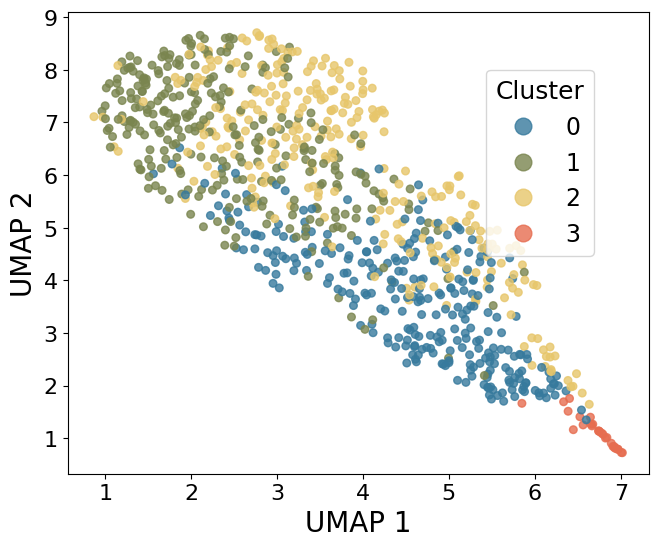

In [4]:
import umap

CLUSTER_COLORS = ['#377A9D', '#7A854F', '#e7c66b', '#e66d50']
cosine_flat = cosine.reshape(n_cells, -1)

reducer = umap.UMAP(random_state=1)
coords = reducer.fit_transform(cosine_flat)

fig = plt.figure(figsize=(7.5, 6))
sc = plt.scatter(coords[:, 1], coords[:, 0], alpha=0.8, s=30,
                 c=cluster_labels, cmap=ListedColormap(CLUSTER_COLORS))
handles, _ = sc.legend_elements()
plt.legend(handles, CLUSTERS, title='Cluster', bbox_to_anchor=(0.7, 0.9), loc='upper left',
           fontsize=17, title_fontsize=18, markerscale=2)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('UMAP 1', fontsize=20)
plt.ylabel('UMAP 2', fontsize=20)
plt.show()

## Localization and splicing across the clusters

Each gene's relative distance to the nuclear center, and its log1p-transformed unspliced/spliced
expression ratio, averaged within each cluster. P values are from one-sided Wilcoxon signed-rank
tests against cluster 0.

In [5]:
MIN_COUNTS = 5

_ii, _jj = np.meshgrid(np.arange(12), np.arange(12), indexing='ij')
D = np.sqrt((_ii + 0.5 - 6) ** 2 + (_jj + 0.5 - 6) ** 2) / 6

def distance_ratio(img):
    total = img.sum(axis=(-1, -2))
    r = np.where(total != 0, (img * D).sum(axis=(-1, -2)) / np.where(total == 0, 1, total), 0.0)
    return np.where(total != 0, np.minimum(r, 1.0), 0.0)

splice = np.load(DATA_DIR / 'splice_unsplice.npz')
train_valid = truth_train.sum(axis=(-1, -2)) >= MIN_COUNTS
train_dist = distance_ratio(truth_train)
in_train = np.isin(all_cell_names, train_cell_names)
train_us = np.log1p(splice['unsplice'][in_train]) - np.log1p(splice['splice'][in_train])

dist_by_cluster, us_by_cluster = [], []
for k in CLUSTERS:
    m = cluster_labels == k
    dist_by_cluster.append((train_dist[m] * train_valid[m]).sum(0) / train_valid[m].sum(0))
    us_by_cluster.append(train_us[m].mean(0))

p_dist = [wilcoxon(dist_by_cluster[0], dist_by_cluster[k], alternative='greater')[1] for k in [1, 2, 3]]
p_us = [wilcoxon(us_by_cluster[k], us_by_cluster[0], alternative='greater')[1] for k in [1, 2, 3]]

print('(cell, gene) images kept: %d / %d' % (train_valid.sum(), train_valid.size))
print('median distance ', ['%.4f' % np.median(x) for x in dist_by_cluster])
print('median US ratio ', ['%.4f' % np.median(x) for x in us_by_cluster])
print('p distance 0>k  ', ['%.2e' % p for p in p_dist])
print('p US ratio  k>0 ', ['%.2e' % p for p in p_us])

(cell, gene) images kept: 102348 / 107100
median distance  ['0.5973', '0.5903', '0.5959', '0.5515']
median US ratio  ['-0.7097', '-0.6140', '-0.6161', '-0.1647']
p distance 0>k   ['3.38e-16', '1.39e-02', '1.20e-12']
p US ratio  k>0  ['6.19e-10', '4.10e-11', '3.48e-19']


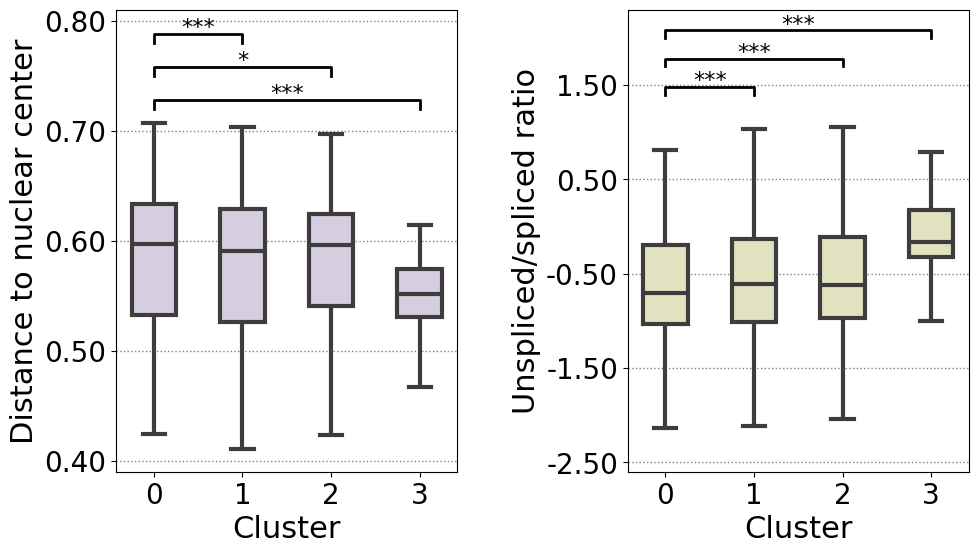

In [6]:
def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

PANELS = [(dist_by_cluster, p_dist, '#D7CAE4', 'Distance to nuclear center',
           (0.39, 0.81), np.arange(0.4, 0.82, 0.1), [0.78, 0.75, 0.72], 0.008),
          (us_by_cluster, p_us, '#e8e7bb', 'Unspliced/spliced ratio',
           (-2.6, 2.3), np.arange(-2.5, 2.5, 1), [1.4, 1.7, 2], 0.08)]

fig, ax = plt.subplots(1, 2, figsize=(11, 6), gridspec_kw={'wspace': 0.5})

for a, (values, pvals, color, ylabel, ylim, yticks, bracket_y, tick) in zip(ax, PANELS):
    sns.boxplot(data=values, color=color, width=0.5, linewidth=3, showfliers=False, ax=a, zorder=10)
    a.set_ylim(*ylim)
    a.set_yticks(yticks)
    a.set_yticklabels(['%.2f' % t for t in yticks], fontsize=20)
    a.set_xticks(CLUSTERS)
    a.set_xticklabels(CLUSTERS, fontsize=20)
    a.set_ylabel(ylabel, fontsize=22)
    a.grid(axis='y', color='gray', linestyle=':', linewidth=1)
    for k, (p, y) in enumerate(zip(pvals, bracket_y), start=1):
        a.plot([0, 0, k, k], [y, y + tick, y + tick, y], color='black', lw=2, clip_on=False)
        a.text(k / 2, y + tick, stars(p), size=16, ha='center')
ax[0].set_xlabel('Cluster', fontsize=22)
ax[1].set_xlabel('Cluster', fontsize=22)
plt.show()

## Marker gene expression

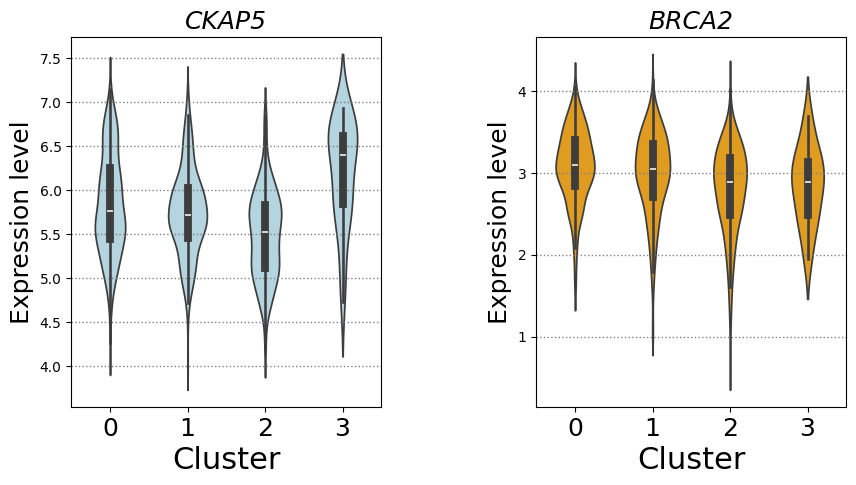

In [7]:
exp_level = truth_train.sum((2, 3))

fig, ax = plt.subplots(1, 2, figsize=(10, 4.8), gridspec_kw={'wspace': 0.5})
for a, (gene, color) in zip(ax, [('CKAP5', 'lightblue'), ('BRCA2', 'orange')]):
    g = gene_names.index(gene)
    sns.violinplot(data=[np.log1p(exp_level[cluster_labels == k][:, g]) for k in CLUSTERS],
                   color=color, width=0.5, ax=a)
    a.set_title(gene, fontsize=18, fontstyle='italic')
    a.set_xticks(CLUSTERS)
    a.set_xticklabels(CLUSTERS, fontsize=18)
    a.set_xlabel('Cluster', fontsize=22)
    a.set_ylabel('Expression level', fontsize=18)
    a.grid(axis='y', color='gray', linestyle=':', linewidth=1)
plt.show()

## Co-localization network of the clusters

The top 50 co-localized gene pairs of each cluster. Edge colors denote the cluster assignment of
each identified gene pair; gene pairs shared among all clusters are connected by purple edges.

In [8]:
K_NN = 10
TOP_PAIRS = 50
DETECT = 1

train_counts = truth_train.sum(axis=(-1, -2))
pairs_per_cluster = []
for k in CLUSTERS:
    cells = np.flatnonzero(cluster_labels == k)
    detected = train_counts[cells] >= DETECT
    coloc = np.zeros((n_genes, n_genes))
    for n, c in enumerate(cells):
        neighbours = np.argsort(1.0 - cosine[c], axis=1)[:, 1:K_NN + 1]
        rows = np.flatnonzero(detected[n])
        coloc[rows[:, None], neighbours[rows]] += 1
    coloc /= np.maximum(detected.sum(0), 1)[:, None]
    coloc = np.triu(np.maximum(coloc, coloc.T), 1)

    pairs = []
    for _ in range(TOP_PAIRS):
        i, j = np.unravel_index(np.argmax(coloc), coloc.shape)
        pairs.append((gene_names[i], gene_names[j]))
        coloc[i, j] = 0
    pairs_per_cluster.append(pairs)

union_pairs = sorted(set().union(*[set(p) for p in pairs_per_cluster]))
pair_clusters = {p: [k for k in CLUSTERS if p in pairs_per_cluster[k]] for p in union_pairs}
n_four = sum(1 for c in pair_clusters.values() if len(c) == len(CLUSTERS))
n_specific = [sum(1 for c in pair_clusters.values() if c == [k]) for k in CLUSTERS]
print('union %d pairs over %d genes | in all four clusters: %d'
      % (len(union_pairs), len({g for p in union_pairs for g in p}), n_four))
print('number of cluster 0/1/2/3 specific pairs:', *n_specific)

union 76 pairs over 27 genes | in all four clusters: 25
number of cluster 0/1/2/3 specific pairs: 1 0 1 19


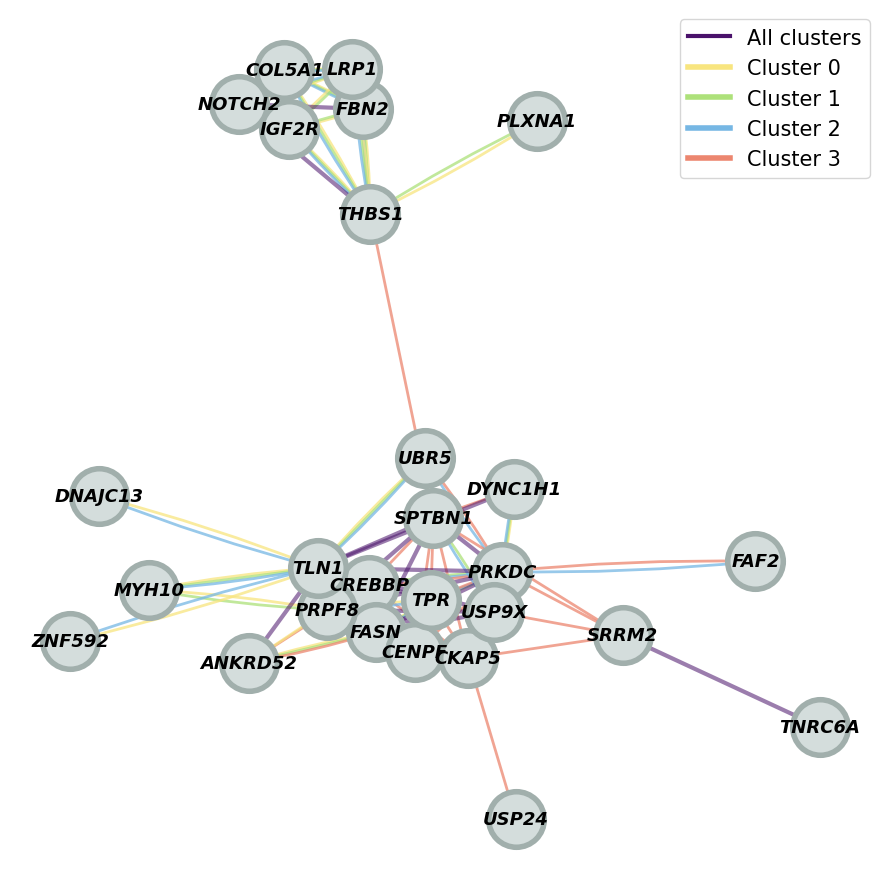

In [9]:
EDGE_COLORS = ['#F8E57F', '#ADE17A', '#76B7E4', '#EC866F']
SHARED_COLOR, SHARED_WIDTH, SHARED_ALPHA = '#4A126B', 3, 0.55
CLUSTER_WIDTH, CLUSTER_ALPHA, ARC = 2.0, 0.75, 0.03
LAYOUT_SEED = 5

graph = nx.Graph()
graph.add_edges_from(union_pairs)
pos = nx.spring_layout(graph, seed=LAYOUT_SEED)

fig, ax = plt.subplots(figsize=(9, 9))
for (u, v), clusters in pair_clusters.items():
    if len(clusters) == len(CLUSTERS):
        continue
    rads = [0.0] if len(clusters) == 1 else np.linspace(-ARC, ARC, len(clusters))
    for k, rad in zip(clusters, rads):
        ax.add_patch(FancyArrowPatch(pos[u], pos[v], connectionstyle=f'arc3,rad={rad}',
                                     arrowstyle='-', linewidth=CLUSTER_WIDTH, color=EDGE_COLORS[k],
                                     alpha=CLUSTER_ALPHA, zorder=1))
for (u, v), clusters in pair_clusters.items():
    if len(clusters) == len(CLUSTERS):
        ax.add_patch(FancyArrowPatch(pos[u], pos[v], arrowstyle='-', linewidth=SHARED_WIDTH,
                                     color=SHARED_COLOR, alpha=SHARED_ALPHA, zorder=2))

nodes = nx.draw_networkx_nodes(graph, pos, node_color='#D4DDDC', node_size=1600,
                               edgecolors='#A1AFAC', linewidths=4, ax=ax)
nodes.set_zorder(3)
for text in nx.draw_networkx_labels(graph, pos, font_size=13, font_color='black',
                                    font_weight='bold', ax=ax).values():
    text.set_fontstyle('italic')
    text.set_zorder(4)

ax.legend([Line2D([0], [0], color=SHARED_COLOR, lw=SHARED_WIDTH)]
          + [Line2D([0], [0], color=EDGE_COLORS[k], lw=4) for k in CLUSTERS],
          ['All clusters'] + ['Cluster %d' % k for k in CLUSTERS], fontsize=15,
          loc='upper right')
ax.margins(0.08)
ax.set_axis_off()
plt.tight_layout()
plt.show()